In [1]:
# Import required libraries and initialize Spark session   
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window

spark = SparkSession.builder.getOrCreate()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/06/29 12:53:01 WARN Utils: Your hostname, AS-MAC-1343s-MacBook-Air.local, resolves to a loopback address: 127.0.0.1; using 10.20.1.101 instead (on interface en0)
26/06/29 12:53:01 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/06/29 12:53:01 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [2]:
# Load sales dataset and inspect schema structure
df = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .csv("masked_sales_export.csv")
)

df.printSchema()
df.show(5)

root
 |-- calendar_date: date (nullable = true)
 |-- masked_store_id: integer (nullable = true)
 |-- masked_product_id: integer (nullable = true)
 |-- sales_value_ty: double (nullable = true)
 |-- sales_volume_ty: double (nullable = true)

+-------------+---------------+-----------------+--------------+---------------+
|calendar_date|masked_store_id|masked_product_id|sales_value_ty|sales_volume_ty|
+-------------+---------------+-----------------+--------------+---------------+
|   2025-01-01|            373|             4772|           0.0|            0.0|
|   2025-01-02|            373|             4772|           0.0|            0.0|
|   2025-01-03|            373|             4772|           0.0|            0.0|
|   2025-01-04|            373|             4772|           0.0|            0.0|
|   2025-01-05|            373|             4772|           0.0|            0.0|
+-------------+---------------+-----------------+--------------+---------------+
only showing top 5 rows


In [3]:
# Convert calendar dates into Spark date format
df = df.withColumn(
    "calendar_date",
    F.to_date("calendar_date")
)

In [4]:
# Calculate dataset scale and unique store/product counts
print("Rows:", df.count()) 

df.select(
    F.countDistinct("masked_store_id")
).show()

df.select(
    F.countDistinct("masked_product_id")
).show()

Rows: 3304811


+-------------------------------+
|count(DISTINCT masked_store_id)|
+-------------------------------+
|                            200|
+-------------------------------+

+---------------------------------+
|count(DISTINCT masked_product_id)|
+---------------------------------+
|                               50|
+---------------------------------+



## Observation: Dataset Overview

The dataset consists of approximately 3.3 million daily sales observations spanning 200 retail stores and 50 products, providing extensive coverage across store–product combinations. Such scale enables comprehensive analysis of demand variability, sparsity, promotional effects, and temporal purchasing behavior. The large number of observations also supports reliable aggregation and statistical forecasting at the weekly store–product level.

## Data Preparation

In [5]:
# Create weekly aggregation timestamps from daily sales records
df = df.withColumn(
    "week_start",
    F.to_date(
        F.date_trunc(
            "week",
            F.col("calendar_date")
        )
    )
)

In [6]:
# Generate sequential week identifiers for time-series analysis
week_lookup = (
    df.select("week_start")
      .distinct()
      .orderBy("week_start")
)

window_spec = Window.orderBy("week_start")

week_lookup = week_lookup.withColumn(
    "week_id",
    F.row_number().over(window_spec)
)

df = df.join(
    week_lookup,
    on="week_start",
    how="left"
)

Sequential week identifiers are generated solely for indexing and visualization purposes. The actual temporal ordering throughout the analysis is preserved using week_start.

Weekly Aggregation

Daily retail demand is highly sparse, with frequent zero-demand observations across many store–product combinations. To reduce noise while preserving meaningful purchasing patterns, daily transactions are aggregated into weekly demand. Weekly aggregation provides a balance between retaining temporal variation and improving forecast stability, making it an appropriate granularity for intermittent demand forecasting.

In [7]:
# Join week identifiers back into the dataset
weekly_df = (
    df.groupBy(
        "week_id",
        "week_start",
        "masked_store_id",
        "masked_product_id"
    )
    .agg(
        F.sum("sales_volume_ty")
         .alias("weekly_volume"),

        F.sum("sales_value_ty")
         .alias("weekly_value")
    )
)

In [8]:
# Aggregate daily sales into weekly outlet-product demand
weekly_df = weekly_df.withColumn(
    "weekly_avg_price",
    F.when(
        F.col("weekly_volume") > 0,
        F.col("weekly_value")
        /
        F.col("weekly_volume")
    )
)

In [9]:
# Compute average selling price per outlet-product-week
weekly_df.cache()

print(
    "Weekly rows:",
    weekly_df.count()
)

26/06/29 12:53:09 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/06/29 12:53:09 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/06/29 12:53:11 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/06/29 12:53:11 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/06/29 12:53:12 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/06/29 12:53:12 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/06/29 1

Weekly rows: 477708


## Observation: Weekly Aggregation

Aggregating daily sales into weekly intervals substantially reduces short-term noise while preserving meaningful purchasing behavior and demand trends. The transformation produces approximately 478 thousand store–product–week observations spanning 70 weeks, creating a consistent time-series structure suitable for forecasting. Weekly aggregation also mitigates the impact of daily demand sparsity without excessively smoothing the data, making it an appropriate forecasting granularity for intermittent retail demand.

In [10]:
# Validate weekly aggregation dimensions
weekly_df.select(
    F.countDistinct("week_id").alias("weeks"),
    F.countDistinct("masked_store_id").alias("stores"),
    F.countDistinct("masked_product_id").alias("products")
).show()

+-----+------+--------+
|weeks|stores|products|
+-----+------+--------+
|   70|   200|      50|
+-----+------+--------+



In [11]:
weekly_df.columns

['week_id',
 'week_start',
 'masked_store_id',
 'masked_product_id',
 'weekly_volume',
 'weekly_value',
 'weekly_avg_price']

In [12]:
from pyspark.sql import functions as F

weekly_df.select(F.countDistinct("week_start")).show()

+--------------------------+
|count(DISTINCT week_start)|
+--------------------------+
|                        70|
+--------------------------+



In [13]:
weekly_df.select(
    "masked_store_id",
    "masked_product_id"
).distinct().count()

7720

In [14]:
series_lengths = (
    weekly_df
    .groupBy("masked_store_id", "masked_product_id")
    .count()
)

series_lengths.show(5)

+---------------+-----------------+-----+
|masked_store_id|masked_product_id|count|
+---------------+-----------------+-----+
|            979|             2438|   70|
|            194|             3929|   70|
|            266|             3929|   65|
|            266|             2471|   70|
|            396|             9696|   70|
+---------------+-----------------+-----+
only showing top 5 rows


In [15]:
series_lengths.describe().show()

+-------+-----------------+-----------------+------------------+
|summary|  masked_store_id|masked_product_id|             count|
+-------+-----------------+-----------------+------------------+
|  count|             7720|             7720|              7720|
|   mean|571.6366580310881|5769.666968911917| 61.87927461139896|
| stddev|272.3145428320452|2543.185311176201|15.453223275149888|
|    min|              100|             1124|                 1|
|    max|              999|             9824|                70|
+-------+-----------------+-----------------+------------------+



Observation: Time Series Coverage

The weekly dataset contains 7,720 store–product time series with an average history length of approximately 62 weeks, although some combinations contain substantially shorter histories. This variation reflects differences in product availability and sales continuity across stores. Unequal history lengths reinforce the need for forecasting approaches capable of handling sparse and intermittent demand patterns.

In [16]:
weekly_df.printSchema()

root
 |-- week_id: integer (nullable = true)
 |-- week_start: date (nullable = true)
 |-- masked_store_id: integer (nullable = true)
 |-- masked_product_id: integer (nullable = true)
 |-- weekly_volume: double (nullable = true)
 |-- weekly_value: double (nullable = true)
 |-- weekly_avg_price: double (nullable = true)



## Promotion Detection

Since explicit promotion flags were unavailable, promotional events were inferred from pricing behaviour. A rolling estimate of regular price was computed for each store–product combination, allowing temporary price reductions to be identified as potential promotional periods.

In [17]:
# Define rolling windows for price analysis
price_window = (
    Window
    .partitionBy(
        "masked_store_id",
        "masked_product_id",
    )
    .orderBy("week_id")
)

In [18]:
# Estimate regular price using previous weeks
reg_price_window = (
    price_window
    .rowsBetween(-7, 0)
)


In [19]:
# Estimate regular price using historical weeks
weekly_df = weekly_df.withColumn(
    "regular_price",
    F.max(
        "weekly_avg_price"
    ).over(reg_price_window)
)


In [20]:
# Calculate percentage discount from regular price
weekly_df = weekly_df.withColumn(
    "price_drop_pct",
    F.when(
        F.col("regular_price") > 0,
        (
            (F.col("regular_price") - F.col("weekly_avg_price"))
            / F.col("regular_price")
        ) * 100
    )
)

In [21]:
# Identify promotional weeks using price-drop thresholds
weekly_df = weekly_df.withColumn(
    "promo_flag",

    F.when(
        F.col("price_drop_pct") > 5,
        1
    ).otherwise(0)
)

Promotional periods were defined as weeks where the observed selling price was more than 5% below the estimated regular price. This threshold was selected to exclude minor pricing fluctuations while capturing meaningful temporary discounts likely to influence purchasing behaviour.

In [22]:
# Validate promotion detection on a sample series
sample = (
    weekly_df
    .filter(
        (F.col("masked_store_id") == 373)
        &
        (F.col("masked_product_id") == 4772)
    )
    .select(
        "week_id",
        "weekly_avg_price",
        "regular_price",
        "price_drop_pct",
        "promo_flag"
    )
    .orderBy("week_id")
)

sample.show(100, truncate=False)

+-------+------------------+------------------+----------------------+----------+
|week_id|weekly_avg_price  |regular_price     |price_drop_pct        |promo_flag|
+-------+------------------+------------------+----------------------+----------+
|1      |NULL              |NULL              |NULL                  |0         |
|2      |NULL              |NULL              |NULL                  |0         |
|3      |NULL              |NULL              |NULL                  |0         |
|4      |1.8166666666666664|1.8166666666666664|0.0                   |0         |
|5      |NULL              |1.8166666666666664|NULL                  |0         |
|6      |1.65              |1.8166666666666664|9.174311926605498     |1         |
|7      |1.6499999999999997|1.8166666666666664|9.17431192660551      |1         |
|8      |1.775             |1.8166666666666664|2.293577981651368     |0         |
|9      |1.65              |1.8166666666666664|9.174311926605498     |1         |
|10     |1.55   

In [23]:
# Measure promotional coverage across the dataset
weekly_df.groupBy("promo_flag").count().show()

+----------+------+
|promo_flag| count|
+----------+------+
|         1| 57108|
|         0|420600|
+----------+------+



Observation: Promotion Detection

Approximately 12% of store–product–week observations were identified as promotional periods using the price-drop methodology. This indicates that promotions represent occasional but meaningful business events rather than routine pricing behaviour. The imbalance between promotional and non-promotional periods suggests that promotion-related demand uplift should be treated as an explanatory feature rather than the dominant driver of demand.

### Promotion Validation

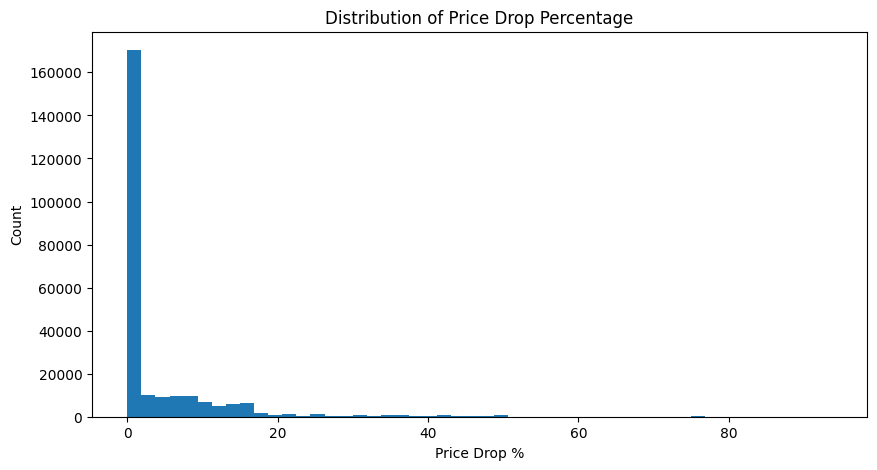

In [24]:
import matplotlib.pyplot as plt

pdf = (
    weekly_df
    .filter(F.col("price_drop_pct").isNotNull())
    .select("price_drop_pct")
    .toPandas()
)

plt.figure(figsize=(10,5))
plt.hist(pdf["price_drop_pct"], bins=50)
plt.xlabel("Price Drop %")
plt.ylabel("Count")
plt.title("Distribution of Price Drop Percentage")
plt.show()

In [25]:
weekly_df.select(
    F.expr("""
        percentile_approx(
            price_drop_pct,
            array(0.25,0.5,0.75,0.9,0.95)
        )
    """).alias("percentiles")
).show(truncate=False)

+---------------------------------------------------------------------+
|percentiles                                                          |
+---------------------------------------------------------------------+
|[0.0, 0.0, 4.347826086956532, 12.962962962962965, 16.666666666666664]|
+---------------------------------------------------------------------+



The median observed price reduction is 0%, indicating that most weeks occur under regular pricing conditions. Promotional discounts are therefore concentrated within a relatively small subset of observations.

## Observation: Promotion Detection

Approximately 12% of all outlet-product weeks were classified as promotional periods, indicating that promotions are frequent enough to influence demand behavior while remaining distinct from normal pricing activity.

In [26]:
weekly_df.groupBy(
    "promo_flag"
).agg(
    F.avg("weekly_volume")
     .alias("avg_volume"),

    F.avg("weekly_value")
     .alias("avg_value")
).show()

+----------+------------------+------------------+
|promo_flag|        avg_volume|         avg_value|
+----------+------------------+------------------+
|         1|3.4983890173005534|15.730697800658401|
|         0|1.2665620542082738| 6.778194151212439|
+----------+------------------+------------------+



### Discount Depth Analysis

In [27]:
#discount depth analysis
# # Analyze demand behavior across different discount-depth buckets to understand whether larger discounts consistently generate higher sales volume. 
weekly_df = weekly_df.withColumn(
    "discount_bucket",
    F.when(F.col("price_drop_pct").isNull(), "No Price Data")
     .when(F.col("price_drop_pct") == 0, "0%")
     .when(F.col("price_drop_pct") <= 5, "0-5%")
     .when(F.col("price_drop_pct") <= 10, "5-10%")
     .when(F.col("price_drop_pct") <= 20, "10-20%")
     .when(F.col("price_drop_pct") <= 40, "20-40%")
     .otherwise("40%+")
)

In [28]:
weekly_df = weekly_df.filter(
    F.col("weekly_volume") >= 0
)

In [29]:
#calculate 
discount_analysis = (
    weekly_df
    .groupBy("discount_bucket")
    .agg(
        F.count("*").alias("weeks"),
        F.avg("weekly_volume").alias("avg_weekly_volume")
    )
)

In [30]:
df = discount_analysis.toPandas()

In [31]:
discount_analysis.orderBy("discount_bucket").show(truncate=False)

+---------------+------+--------------------+
|discount_bucket|weeks |avg_weekly_volume   |
+---------------+------+--------------------+
|0%             |151718|2.5819546790756536  |
|0-5%           |35209 |4.004544292652446   |
|10-20%         |23990 |3.259274697790746   |
|20-40%         |6556  |3.278523489932886   |
|40%+           |2574  |3.237762237762238   |
|5-10%          |23988 |3.825579456394864   |
|No Price Data  |233657|2.995844335928305E-5|
+---------------+------+--------------------+



## Observation: Discount Depth Analysis

Moderate discounts between 0–10% correspond to the highest average weekly sales volume, whereas progressively deeper discounts do not generate proportionally greater demand. This suggests that relatively small price reductions are sufficient to stimulate purchasing behaviour for many products, while aggressive discounting provides diminishing returns. Additionally, the large proportion of observations with missing price information primarily reflects weeks with zero sales volume, during which average selling price cannot be computed.

In [32]:
# Compare average demand during promotion and non-promotion periods
store_promo = (
    weekly_df
    .groupBy(
        "masked_store_id",
        "promo_flag"
    )
    .agg(
        F.avg("weekly_volume")
         .alias("avg_volume")
    )
)

In [33]:
# Calculate promotion uplift at store level
store_promo_pivot = (
    store_promo
    .groupBy("masked_store_id")
    .pivot("promo_flag")
    .agg(
        F.first("avg_volume")
    )
)

In [34]:
store_promo_pivot = (
    store_promo_pivot
    .withColumnRenamed("0", "non_promo_volume")
    .withColumnRenamed("1", "promo_volume")
)

In [35]:
store_promo_pivot = (
    store_promo_pivot
    .withColumn(
        "promo_lift",

        F.when(
            F.col("non_promo_volume") > 0,

            F.col("promo_volume")
            /
            F.col("non_promo_volume")
        )
    )
)

In [36]:
# Summarize store-level promotion uplift statistics
store_promo_pivot.orderBy(
    F.desc("promo_lift")
).show(20, truncate=False)

+---------------+-------------------+------------------+------------------+
|masked_store_id|non_promo_volume   |promo_volume      |promo_lift        |
+---------------+-------------------+------------------+------------------+
|691            |0.6064171122994653 |3.4312267657992566|5.658195813090485 |
|488            |0.6837996096291477 |3.185430463576159 |4.658426853012899 |
|127            |0.7616822429906542 |3.3560975609756096|4.406164896004788 |
|928            |1.1436314363143631 |4.855555555555555 |4.245734597156398 |
|463            |1.1475118483412323 |4.867724867724868 |4.24198222855941  |
|798            |0.6516072980017377 |2.7044025157232703|4.150356394129979 |
|915            |0.5375418460066954 |2.2302158273381294|4.1489157428505585|
|665            |0.8552989130434783 |3.4934210526315788|4.084444630241211 |
|125            |0.5852187028657617 |2.371794871794872 |4.052835051546391 |
|467            |0.5437469105289174 |2.1951219512195124|4.037028824833703 |
|786        

In [37]:
promo_lift_df = (
    store_promo_pivot
    .filter(F.col("promo_lift").isNotNull())
    .select("promo_lift")
    .toPandas()
)

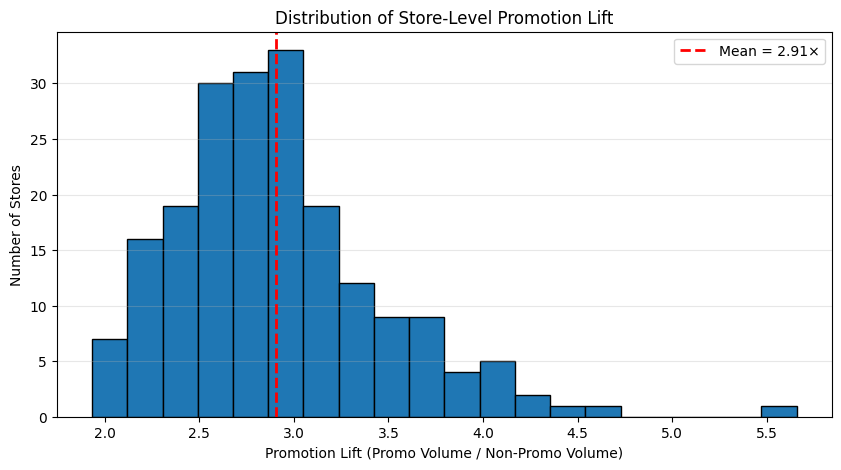

In [38]:
mean_lift = promo_lift_df["promo_lift"].mean()

plt.figure(figsize=(10,5))

plt.hist(
    promo_lift_df["promo_lift"],
    bins=20,
    edgecolor="black"
)

plt.axvline(
    mean_lift,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean = {mean_lift:.2f}×"
)

plt.title("Distribution of Store-Level Promotion Lift")
plt.xlabel("Promotion Lift (Promo Volume / Non-Promo Volume)")
plt.ylabel("Number of Stores")
plt.legend()

plt.grid(axis="y", alpha=0.3)

plt.show()

## Observation: Store-Level Promotion Impact

Promotion effectiveness varies considerably across stores. On average, stores experience approximately 2.9× higher weekly demand during promotional periods compared with regular pricing, although the magnitude of uplift differs substantially between outlets. This variability suggests that promotional response is influenced by store-level characteristics and should be considered when interpreting demand behaviour.

In [39]:
store_promo_pivot.select(
    F.avg("promo_lift").alias("avg_lift"),
    F.min("promo_lift").alias("min_lift"),
    F.max("promo_lift").alias("max_lift")
).show()

+-----------------+------------------+-----------------+
|         avg_lift|          min_lift|         max_lift|
+-----------------+------------------+-----------------+
|2.906392149248131|1.9337272911460794|5.658195813090485|
+-----------------+------------------+-----------------+



## Observation: Store-Level Promotion Lift

The average promotion uplift across stores is approximately 2.9× meaning stores sell nearly three times more volume during promotional periods than during regular pricing periods, with some stores experiencing demand increases above 5×. This highlights substantial variation in promotion effectiveness across outlets.

## Representative Time Series Behaviour

In [40]:
# Select representative product for demand visualization
product_id = 4772

In [41]:
product_df = weekly_df.filter(
    F.col("masked_product_id") == product_id
)

In [42]:
product_df.select(
    F.countDistinct("masked_store_id")
).show()

+-------------------------------+
|count(DISTINCT masked_store_id)|
+-------------------------------+
|                            199|
+-------------------------------+



In [43]:
# Identify top-selling stores for the selected product
top_stores = (
    product_df
    .groupBy("masked_store_id")
    .agg(
        F.sum("weekly_volume")
        .alias("total_volume")
    )
    .orderBy(
        F.desc("total_volume")
    )
)

top_stores.show(10)

+---------------+------------+
|masked_store_id|total_volume|
+---------------+------------+
|            925|      1119.0|
|            998|       695.0|
|            643|       671.0|
|            452|       660.0|
|            983|       644.0|
|            510|       643.0|
|            489|       581.0|
|            956|       570.0|
|            171|       539.0|
|            858|       529.0|
+---------------+------------+
only showing top 10 rows


In [44]:
# Convert selected series to pandas for visualization
store_id = 643

plot_df = (
    product_df
    .filter(
        F.col("masked_store_id") == store_id
    )
    .orderBy("week_id")
    .toPandas()
)

The representative store was selected from the highest-selling outlets for the chosen product to ensure sufficient historical observations and clear visualization of demand behaviour.

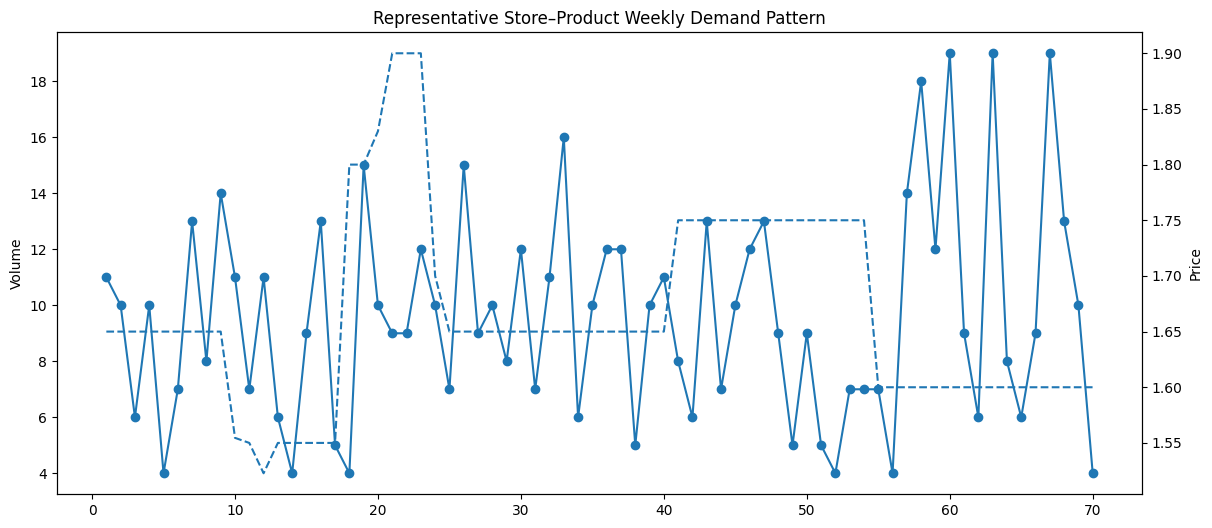

In [45]:
# Visualize demand and price behavior over time
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(14,6))

ax1.plot(
    plot_df["week_id"],
    plot_df["weekly_volume"],
    marker="o"
)

ax1.set_ylabel("Volume")

ax2 = ax1.twinx()

ax2.plot(
    plot_df["week_id"],
    plot_df["weekly_avg_price"],
    linestyle="--"
)

ax2.set_ylabel("Price")

plt.title(
    f"Representative Store–Product Weekly Demand Pattern"
)

plt.show()

This visualization is intended to illustrate typical demand behaviour rather than represent all store-product combinations.

## Observation: Representative Demand Pattern

The selected store–product series exhibits irregular demand spikes separated by periods of relatively stable purchasing activity, reflecting the variability commonly observed in retail demand. Changes in selling price often coincide with increases in weekly sales volume, providing visual evidence that promotional activity contributes to demand fluctuations. This behaviour supports the inclusion of price- and promotion-related features within the forecasting pipeline.

In [46]:
# Measure promotional lift for each product
product_promo = (
    weekly_df
    .groupBy(
        "masked_product_id",
        "promo_flag"
    )
    .agg(
        F.avg("weekly_volume")
        .alias("avg_volume")    
    )   
)

In [47]:
product_promo_pivot = (
    product_promo
    .groupBy("masked_product_id")
    .pivot("promo_flag")
    .agg(
        F.first("avg_volume")
    )
)

In [48]:
product_promo_pivot = (
    product_promo_pivot
    .withColumnRenamed(
        "0",
        "non_promo_volume"
    )
    .withColumnRenamed(
        "1",
        "promo_volume"
    )
)

In [49]:
product_promo_pivot = (
    product_promo_pivot
    .withColumn(
        "promo_lift",

        F.when(
            F.col("non_promo_volume") > 0,

            F.col("promo_volume")
            /
            F.col("non_promo_volume")
        )
    )
)

In [50]:
# Calculate product-level promotion uplift
product_counts = (
    weekly_df
    .groupBy("masked_product_id")
    .agg(
        F.sum(
            F.when(
                F.col("promo_flag") == 1,
                1
            ).otherwise(0)
        ).alias("promo_weeks")
    )
)

In [51]:
product_promo_pivot = (
    product_promo_pivot
    .join(
        product_counts,
        on="masked_product_id",
        how="left"
    )
)

In [52]:
for var in sorted(dir()):
    if (
        "promo" in var.lower()
        or "product" in var.lower()
        or "lift" in var.lower()
        or "summary" in var.lower()
    ):
        print(var)

mean_lift
product_counts
product_df
product_id
product_promo
product_promo_pivot
promo_lift_df
store_promo
store_promo_pivot


In [53]:
stats = (
    product_promo_pivot
    .select(
        F.avg("promo_lift").alias("mean"),
        F.min("promo_lift").alias("min"),
        F.max("promo_lift").alias("max")
    )
    .toPandas()
)

print(f"Mean Promotion Lift : {stats['mean'][0]:.2f}×")
print(f"Range               : {stats['min'][0]:.2f}× – {stats['max'][0]:.2f}×")

Mean Promotion Lift : 4.22×
Range               : 1.21× – 29.63×


In [54]:
# Calculate total sales volume for each product
product_volume = (
    weekly_df
    .groupBy("masked_product_id")
    .agg(
        F.sum("weekly_volume")
        .alias("total_volume")
    )
)

product_summary = (
    product_promo_pivot
    .join(
        product_volume,
        on="masked_product_id",
        how="left"
    )
)

product_summary.orderBy(
    F.desc("promo_lift")
).show(20, truncate=False)

+-----------------+-------------------+------------------+------------------+-----------+------------+
|masked_product_id|non_promo_volume   |promo_volume      |promo_lift        |promo_weeks|total_volume|
+-----------------+-------------------+------------------+------------------+-----------+------------+
|8237             |0.08237964626879789|2.440677966101695 |29.627196481737336|236        |1447.0      |
|2359             |0.1911993413228433 |3.460240963855422 |18.09755692626967 |1245       |6398.0      |
|2324             |0.1784332688588008 |2.4871794871794872|13.93898964630672 |429        |3281.0      |
|9754             |0.15380662841483259|1.5617977528089888|10.15429418683216 |801        |3047.0      |
|7908             |0.5021842732327244 |4.837812352663838 |9.633540137609762 |2121       |12790.0     |
|1124             |0.19701108789972682|1.8676671214188267|9.48001019297664  |733        |3821.0      |
|3115             |0.22442196531791908|1.389261744966443 |6.1904000484016

### Distribution of Product Promotion Lift

To understand how promotional responsiveness varies across products, the distribution of promotion lift is examined. This helps identify whether promotion effects are consistent across the product portfolio or concentrated within a subset of highly promotion-sensitive products.

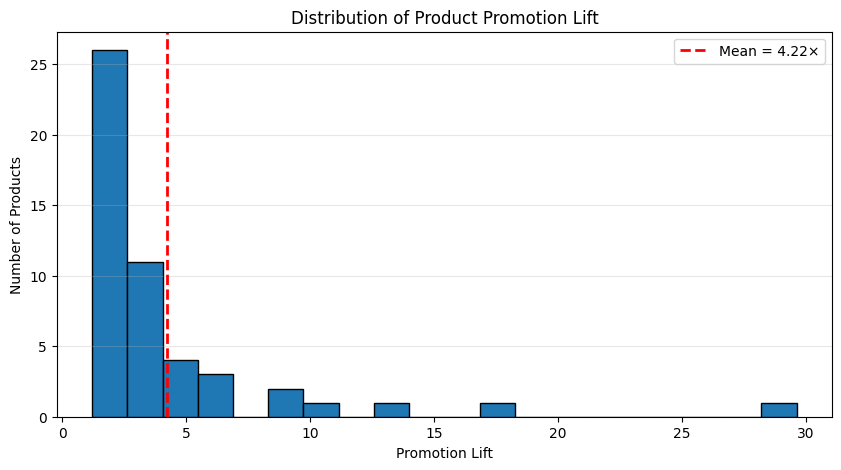

In [55]:
import matplotlib.pyplot as plt

promo_df = (
    product_summary
    .filter(F.col("promo_lift").isNotNull())
    .select("promo_lift")
    .toPandas()
)

mean_lift = promo_df["promo_lift"].mean()

plt.figure(figsize=(10,5))

plt.hist(
    promo_df["promo_lift"],
    bins=20,
    edgecolor="black"
)

plt.axvline(
    mean_lift,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean = {mean_lift:.2f}×"
)

plt.title("Distribution of Product Promotion Lift")
plt.xlabel("Promotion Lift")
plt.ylabel("Number of Products")

plt.legend()

plt.grid(axis="y", alpha=0.3)

plt.show()

### Promotion Lift vs Total Product Sales

Promotion lift is compared with total product sales volume to examine whether high-selling products are also the most promotion-sensitive. This relationship provides insight into whether promotional effectiveness is driven by product popularity or varies independently across the assortment.

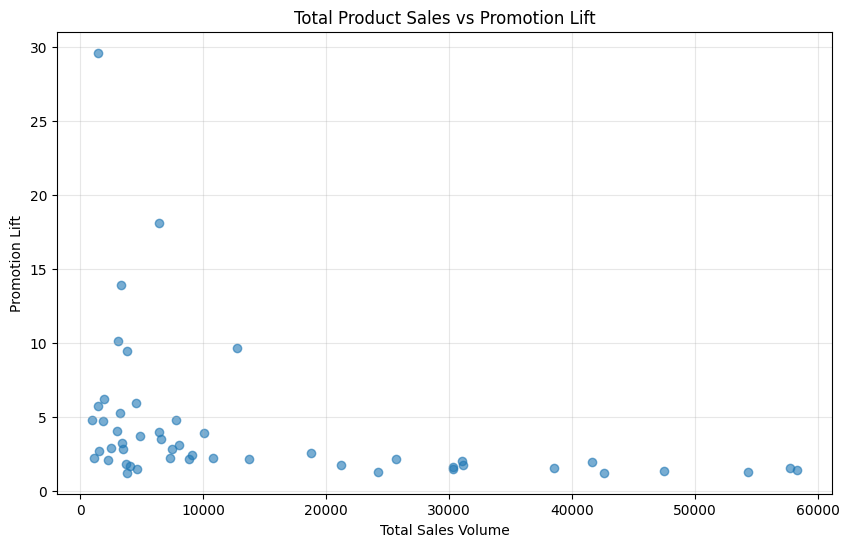

In [56]:
scatter_df = (
    product_summary
    .filter(
        (F.col("promo_lift").isNotNull()) &
        (F.col("total_volume").isNotNull())
    )
    .select(
        "total_volume",
        "promo_lift"
    )
    .toPandas()
)

plt.figure(figsize=(10,6))

plt.scatter(
    scatter_df["total_volume"],
    scatter_df["promo_lift"],
    alpha=0.6
)

plt.title("Total Product Sales vs Promotion Lift")
plt.xlabel("Total Sales Volume")
plt.ylabel("Promotion Lift")

plt.grid(alpha=0.3)

plt.show()

## Observation: Product-Level Promotion Sensitivity

Promotion responsiveness varies considerably across products. While the average product experiences approximately **4.2× higher demand** during promotional periods, several SKUs exhibit substantially larger promotional lifts, indicating strong dependence on temporary price reductions. The broad distribution of promotion lift suggests that products respond differently to promotional activity, highlighting pricing as an important explanatory factor for retail demand forecasting. Products with exceptionally high promotion lift often have relatively low baseline demand, where modest absolute increases in sales translate into large lift ratios.

## Holiday Impact Analysis

Public holidays often influence retail purchasing behaviour through stockpiling, seasonal shopping, and post-holiday demand adjustments. This section evaluates whether demand changes significantly during holiday periods and whether holiday-related features should be incorporated into the forecasting pipeline.

In [57]:
# Load UK holiday calendar
from pyspark.sql import functions as F

holiday_df = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .csv("holiday_df.csv")
)

holiday_df.show()
holiday_df.printSchema()

+------------+-------------+----+
|holiday_date| holiday_name|year|
+------------+-------------+----+
|  2025-01-01|     New Year|2025|
|  2025-12-25|Christmas Day|2025|
|  2025-12-26|   Boxing Day|2025|
|  2025-04-20|   Easter Day|2025|
|  2026-01-01|     New Year|2026|
|  2026-12-25|Christmas Day|2026|
|  2026-12-26|   Boxing Day|2026|
|  2026-04-05|   Easter Day|2026|
+------------+-------------+----+

root
 |-- holiday_date: date (nullable = true)
 |-- holiday_name: string (nullable = true)
 |-- year: integer (nullable = true)



In [58]:
# Convert holiday dates to Spark date format
holiday_df = holiday_df.withColumn(
    "holiday_date",
    F.to_date("holiday_date")
)


In [59]:
# Map holiday dates to weekly periods
holiday_df = holiday_df.withColumn(
    "week_start",
    F.to_date(
        F.date_trunc(
            "week",
            F.col("holiday_date")
        )
    )
)

In [60]:
# Create holiday week indicator table
holiday_weeks = (
    holiday_df
    .select("week_start")
    .distinct()
    .withColumn(
        "holiday_flag",
        F.lit(1)
    )
)

In [61]:
# Join holiday indicators to weekly sales data
weekly_df = (
    weekly_df
    .join(
        holiday_weeks,
        on="week_start",
        how="left"
    )
)

In [62]:
# Prepare holiday dates for weekly analysis
weekly_df = weekly_df.fillna(
    {
        "holiday_flag": 0
    }
)

In [63]:
weekly_df.groupBy(
    "holiday_flag"
).count().show()

+------------+------+
|holiday_flag| count|
+------------+------+
|           0|443449|
|           1| 34243|
+------------+------+



In [64]:
# Flag holiday weeks in the weekly dataset
holiday_summary = (
    weekly_df
    .groupBy("holiday_flag")
    .agg(
        F.avg("weekly_volume")
        .alias("avg_volume")
    )
)

holiday_summary.show()

+------------+------------------+
|holiday_flag|        avg_volume|
+------------+------------------+
|           0|1.5233814937005157|
|           1|  1.66387290833163|
+------------+------------------+



In [65]:
# Compare demand during holiday and non-holiday periods
holiday_weeks = (
    holiday_df
    .withColumn(
        "week_start",
        F.to_date(
            F.date_trunc(
                "week",
                F.col("holiday_date")
            )
        )
    )
    .select("week_start")
    .distinct()
)

In [66]:
holiday_window = (
    holiday_weeks

    .withColumn(
        "prev_week",
        F.date_add(
            F.col("week_start"),
            -7
        )
    )

    .withColumn(
        "next_week",
        F.date_add(
            F.col("week_start"),
            7
        )
    )
)

In [67]:
# Measure demand during holiday and non-holiday periods
holiday_window = (
    holiday_window
    .selectExpr(
        "week_start as holiday_week",
        "prev_week",
        "next_week"
    )
)

In [68]:
# Create pre-holiday, holiday and post-holiday analysis windows
holiday_window_lookup = (

    holiday_window.select(
        F.col("holiday_week")
        .alias("week_start")
    )

    .union(

        holiday_window.select(
            F.col("prev_week")
            .alias("week_start")
        )

    )

    .union(

        holiday_window.select(
            F.col("next_week")
            .alias("week_start")
        )

    )

    .distinct()

    .withColumn(
        "holiday_window_flag",
        F.lit(1)
    )
)

In [69]:
# Create holiday impact analysis windows
weekly_df = (
    weekly_df
    .join(
        holiday_window_lookup,
        on="week_start",
        how="left"
    )
)

In [70]:
weekly_df.groupBy(
    "holiday_window_flag"
).agg(
    F.avg("weekly_volume")
    .alias("avg_volume")
).show()


+-------------------+------------------+
|holiday_window_flag|        avg_volume|
+-------------------+------------------+
|               NULL|1.5156424877404229|
|                  1| 1.619548357942818|
+-------------------+------------------+



In [71]:
# Generate holiday window lookup table
holiday_weeks = (
    holiday_df
    .withColumn(
        "week_start",
        F.to_date(
            F.date_trunc(
                "week",
                F.col("holiday_date")
            )
        )
    )
    .select("week_start")
    .distinct()
)

In [72]:
# Create PRE, HOLIDAY and POST holiday windows

holiday_weeks = (
    holiday_df
    .withColumn(
        "week_start",
        F.to_date(
            F.date_trunc(
                "week",
                F.col("holiday_date")
            )
        )
    )
    .select("week_start")
    .distinct()
)

pre_holiday = (
    holiday_weeks
    .withColumn(
        "week_start",
        F.date_add(
            F.col("week_start"),
            -7
        )
    )
    .withColumn(
        "holiday_period",
        F.lit("PRE")
    )
)

holiday_period = (
    holiday_weeks
    .withColumn(
        "holiday_period",
        F.lit("HOLIDAY")
    )
)

post_holiday = (
    holiday_weeks
    .withColumn(
        "week_start",
        F.date_add(
            F.col("week_start"),
            7
        )
    )
    .withColumn(
        "holiday_period",
        F.lit("POST")
    )
)

In [73]:
# Compare demand inside and outside holiday windows
holiday_periods = (
    pre_holiday
    .union(holiday_period)
    .union(post_holiday)
)

In [74]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window

holiday_periods = (
    holiday_periods
    .withColumn(
        "priority",
        F.when(F.col("holiday_period") == "HOLIDAY", 3)
         .when(F.col("holiday_period") == "PRE", 2)
         .when(F.col("holiday_period") == "POST", 1)
    )
)

window_spec = Window.partitionBy("week_start") \
                    .orderBy(F.desc("priority"))

holiday_periods = (
    holiday_periods
    .withColumn(
        "rn",
        F.row_number().over(window_spec)
    )
    .filter(F.col("rn") == 1)
    .drop("priority", "rn")
)

In [75]:
holiday_periods.groupBy(
    "week_start"
).count().filter(
    F.col("count") > 1
).show()

+----------+-----+
|week_start|count|
+----------+-----+
+----------+-----+



In [76]:
weekly_df = (
    weekly_df
    .join(
        holiday_periods,
        on="week_start",
        how="left"
    )
)

In [77]:
weekly_df = (
    weekly_df
    .fillna(
        {
            "holiday_period": "NORMAL"
        }
    )
)

In [78]:
# Compare demand across holiday periods 
weekly_df.groupBy(
    "holiday_period"
).count().show()

+--------------+------+
|holiday_period| count|
+--------------+------+
|        NORMAL|395813|
|       HOLIDAY| 34243|
|          POST| 26857|
|           PRE| 20779|
+--------------+------+



In [79]:
holiday_summary_pd = (
    weekly_df
    .groupBy("holiday_period")
    .agg(
        F.avg("weekly_volume").alias("avg_volume")
    )
    .toPandas()
)

normal = holiday_summary_pd[
    holiday_summary_pd["holiday_period"] == "NORMAL"
]["avg_volume"].iloc[0]

holiday_summary_pd["uplift_pct"] = (
    (holiday_summary_pd["avg_volume"] - normal)
    / normal
) * 100

holiday_summary_pd

,holiday_period,avg_volume,uplift_pct
0,NORMAL,1.515642,0.000000
1,HOLIDAY,1.663873,9.780039
2,POST,1.572886,3.776850
3,PRE,1.606815,6.015408


### Holiday Demand Comparison

Demand is compared across normal, pre-holiday, holiday, and post-holiday periods to quantify the short-term influence of public holidays on purchasing behaviour.

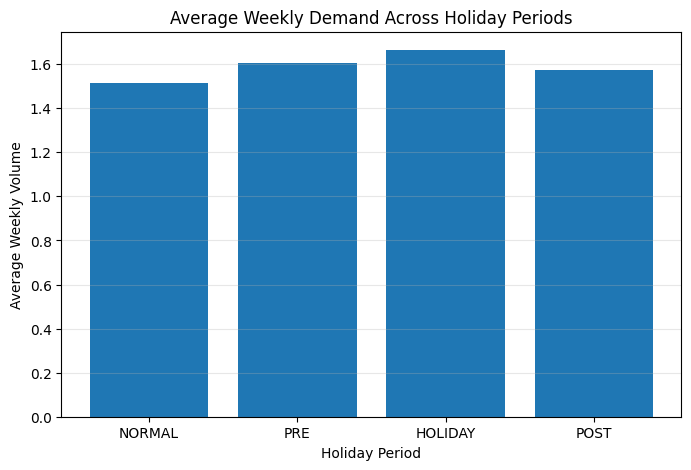

In [80]:
import matplotlib.pyplot as plt

holiday_plot = holiday_summary_pd.sort_values(
    by="holiday_period",
    key=lambda x: x.map({
        "NORMAL":0,
        "PRE":1,
        "HOLIDAY":2,
        "POST":3
    })
)

plt.figure(figsize=(8,5))

plt.bar(
    holiday_plot["holiday_period"],
    holiday_plot["avg_volume"]
)

plt.title("Average Weekly Demand Across Holiday Periods")
plt.xlabel("Holiday Period")
plt.ylabel("Average Weekly Volume")

plt.grid(axis="y", alpha=0.3)

plt.show()

### Holiday Revenue Comparison

Average weekly revenue is also evaluated to determine whether increases in demand translate into corresponding improvements in sales value during holiday periods.

In [81]:
# Compare demand and revenue across holiday periods
(
    weekly_df
    .groupBy("holiday_period")
    .agg(
        F.avg("weekly_volume").alias("avg_volume"),
        F.avg("weekly_value").alias("avg_value")
    )
    .show()
)

+--------------+------------------+-----------------+
|holiday_period|        avg_volume|        avg_value|
+--------------+------------------+-----------------+
|        NORMAL|1.5156424877404229|7.721775358565802|
|       HOLIDAY|  1.66387290833163|8.727428963583794|
|          POST|   1.5728860259895|8.103094910079301|
|           PRE|1.6068145724048317|8.493971317195244|
+--------------+------------------+-----------------+



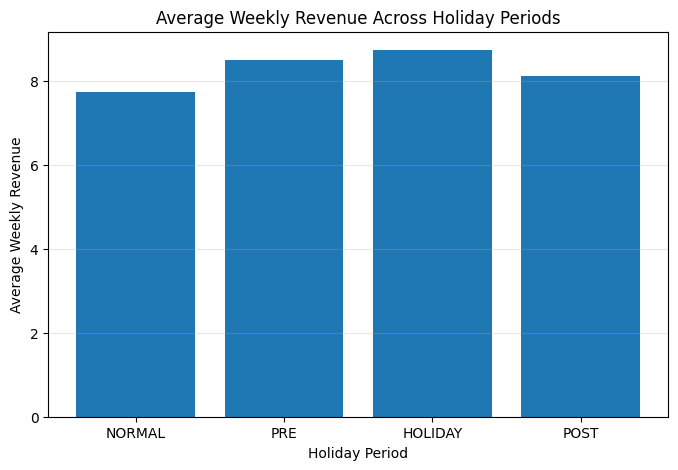

In [82]:
holiday_value = (
    weekly_df
    .groupBy("holiday_period")
    .agg(
        F.avg("weekly_value").alias("avg_value")
    )
    .toPandas()
)

holiday_value = holiday_value.sort_values(
    by="holiday_period",
    key=lambda x: x.map({
        "NORMAL":0,
        "PRE":1,
        "HOLIDAY":2,
        "POST":3
    })
)

plt.figure(figsize=(8,5))

plt.bar(
    holiday_value["holiday_period"],
    holiday_value["avg_value"]
)

plt.title("Average Weekly Revenue Across Holiday Periods")
plt.xlabel("Holiday Period")
plt.ylabel("Average Weekly Revenue")

plt.grid(axis="y", alpha=0.3)

plt.show()

## Observation: Holiday Impact Analysis

Demand exhibits a modest but consistent increase during holiday-related periods. Average weekly demand rises by approximately 6.0% in the week preceding holidays, peaks at nearly 9.8% during holiday weeks, and remains 3.8% above normal levels in the following week. The relatively moderate uplift indicates that holiday effects influence purchasing behaviour but are less pronounced than promotional pricing effects. Consequently, holiday-related indicators represent useful supplementary forecasting features rather than primary demand drivers.

## Demand Pattern Classification (ADI–CV²)

To understand the nature of retail demand across outlet–product combinations, each time series is classified using the ADI–CV² framework. This categorizes demand into Smooth, Erratic, Intermittent, and Lumpy patterns based on demand frequency and variability, providing insight into the suitability of different forecasting approaches.

In [83]:
# Calculate ADI and CV² metrics for outlet-product demand classification
from pyspark.sql import functions as F

demand_stats = (
    weekly_df
    .groupBy(
        "masked_store_id",
        "masked_product_id"
    )
    .agg(
        F.count("*")
            .alias("total_weeks"),

        F.sum(
            F.when(
                F.col("weekly_volume") > 0,
                1
            ).otherwise(0)
        ).alias("non_zero_weeks"),

        F.avg(
            F.when(
                F.col("weekly_volume") > 0,
                F.col("weekly_volume")
            )
        ).alias("mean_demand"),

        F.stddev(
            F.when(
                F.col("weekly_volume") > 0,
                F.col("weekly_volume")
            )
        ).alias("std_demand")
    )
)

In [84]:
# Compute Average Demand Interval (ADI)
demand_stats = demand_stats.withColumn(
    "ADI",
    F.when(
        F.col("non_zero_weeks") > 0,
        F.col("total_weeks") /
        F.col("non_zero_weeks")
    )
)

In [85]:
# Compute squared coefficient of variation (CV²)
demand_stats = demand_stats.withColumn(
    "CV2",
    F.when(
        (F.col("mean_demand") > 0)
        &
        (F.col("std_demand").isNotNull()),

        (
            F.col("std_demand")
            /
            F.col("mean_demand")
        ) ** 2
    )
)

In [86]:
demand_stats = demand_stats.filter(
    F.col("non_zero_weeks") > 0
)

In [87]:
# Calculate ADI and CV² demand statistics
demand_stats = (
    demand_stats
    .withColumn(
        "demand_type",

        F.when(
            (F.col("ADI") < 1.32)
            &
            (F.col("CV2") < 0.49),
            "Smooth"
        )
        .when(
            (F.col("ADI") < 1.32)
            &
            (F.col("CV2") >= 0.49),
            "Erratic"
        )
        .when(
            (F.col("ADI") >= 1.32)
            &
            (F.col("CV2") < 0.49),
            "Intermittent"
        )
        .otherwise(
            "Lumpy"
        )
    )
)

In [88]:
# Count active outlet-product demand series
demand_stats.select(
    F.count("*").alias("total_series")
).show()

+------------+
|total_series|
+------------+
|        7415|
+------------+



In [89]:
# Classify demand patterns using the ADI-CV² framework
demand_stats.groupBy(
    "demand_type"
).count().show()

+------------+-----+
| demand_type|count|
+------------+-----+
|     Erratic|  170|
|       Lumpy|  674|
|      Smooth| 1907|
|Intermittent| 4664|
+------------+-----+



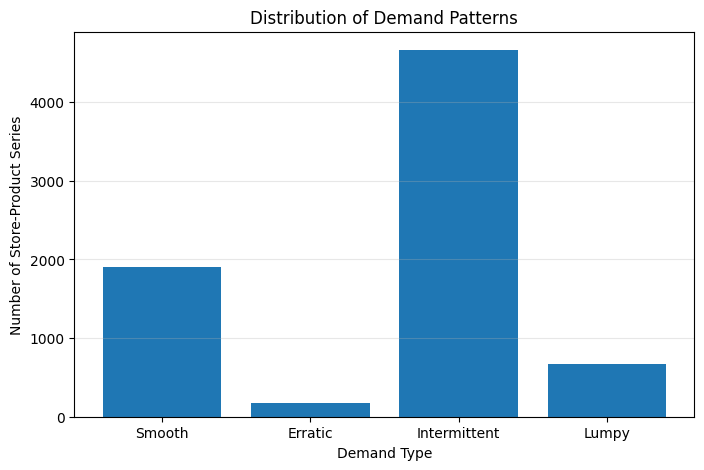

In [90]:
import matplotlib.pyplot as plt

demand_dist = (
    demand_stats
    .groupBy("demand_type")
    .count()
    .toPandas()
)

order = [
    "Smooth",
    "Erratic",
    "Intermittent",
    "Lumpy"
]

demand_dist["demand_type"] = pd.Categorical(
    demand_dist["demand_type"],
    categories=order,
    ordered=True
)

demand_dist = demand_dist.sort_values("demand_type")

plt.figure(figsize=(8,5))

plt.bar(
    demand_dist["demand_type"],
    demand_dist["count"]
)

plt.title("Distribution of Demand Patterns")
plt.xlabel("Demand Type")
plt.ylabel("Number of Store-Product Series")

plt.grid(axis="y", alpha=0.3)

plt.show()

In [91]:
# Compare promotional response across demand categories
weekly_with_type = (
    weekly_df
    .join(
        demand_stats.select(
            "masked_store_id",
            "masked_product_id",
            "demand_type"
        ),
        on=[
            "masked_store_id",
            "masked_product_id"
        ],
        how="inner"
    )
)

In [92]:
weekly_with_type.groupBy(
    "demand_type",
    "promo_flag"
).agg(
    F.avg("weekly_volume")
    .alias("avg_volume")
).show()

+------------+----------+------------------+
| demand_type|promo_flag|        avg_volume|
+------------+----------+------------------+
|      Smooth|         1| 4.300597165263688|
|Intermittent|         0|0.6026569865256074|
|       Lumpy|         0|0.4811637881071056|
|      Smooth|         0|3.2767145293720996|
|     Erratic|         0| 2.969133051036327|
|     Erratic|         1| 4.825210084033613|
|Intermittent|         1|2.3626154758877873|
|       Lumpy|         1| 3.901860744297719|
+------------+----------+------------------+



## Observation: ADI–CV² Demand Classification

The ADI–CV² analysis reveals that **Intermittent demand** is the dominant demand pattern, accounting for approximately **63%** of active outlet–product series. Smooth demand represents only about one-quarter of the portfolio, while Erratic and Lumpy demand occur less frequently. This confirms that the dataset is predominantly characterized by sparse and irregular purchasing behaviour, justifying the evaluation of forecasting methods specifically designed for intermittent demand.

## Promotion Sensitivity by Demand Pattern

Promotion response is evaluated separately for each demand category to determine whether intermittent demand behaves differently from smooth demand during promotional periods.

In [93]:
promo_by_type = (
    weekly_with_type
    .groupBy(
        "demand_type",
        "promo_flag"
    )
    .agg(
        F.avg("weekly_volume")
        .alias("avg_volume")
    )
)

In [94]:
promo_by_type = (
    promo_by_type
    .groupBy("demand_type")
    .pivot("promo_flag")
    .agg(F.first("avg_volume"))
)

In [95]:
promo_by_type = (
    promo_by_type
    .withColumnRenamed("0", "non_promo_volume")
    .withColumnRenamed("1", "promo_volume")
)

In [96]:
promo_by_type = (
    promo_by_type
    .withColumn(
        "promo_lift",
        F.col("promo_volume")
        /
        F.col("non_promo_volume")
    )
)

promo_by_type.show(truncate=False)

+------------+------------------+------------------+------------------+
|demand_type |non_promo_volume  |promo_volume      |promo_lift        |
+------------+------------------+------------------+------------------+
|Erratic     |2.969133051036327 |4.825210084033613 |1.6251242369719514|
|Lumpy       |0.4811637881071056|3.901860744297719 |8.10921528331882  |
|Smooth      |3.2767145293720996|4.300597165263688 |1.3124723337091528|
|Intermittent|0.6026569865256074|2.3626154758877873|3.920332010931392 |
+------------+------------------+------------------+------------------+



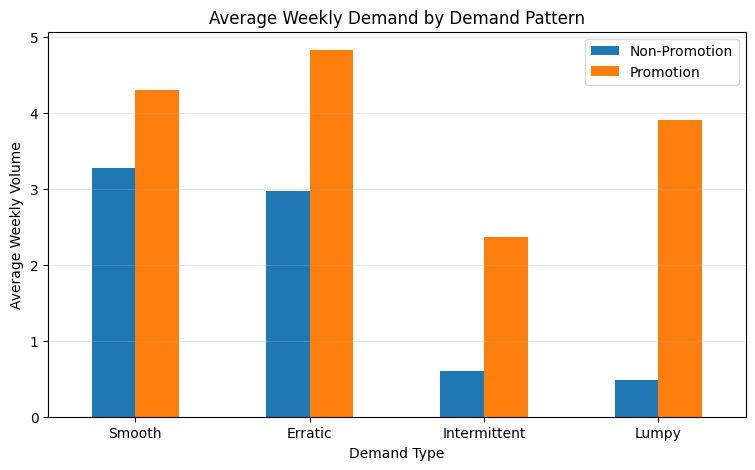

In [97]:
promo_type = (
    weekly_with_type
    .groupBy(
        "demand_type",
        "promo_flag"
    )
    .agg(
        F.avg("weekly_volume")
        .alias("avg_volume")
    )
    .toPandas()
)

pivot = promo_type.pivot(
    index="demand_type",
    columns="promo_flag",
    values="avg_volume"
)

pivot = pivot.reindex(
    ["Smooth","Erratic","Intermittent","Lumpy"]
)

pivot.plot(
    kind="bar",
    figsize=(9,5)
)

plt.title("Average Weekly Demand by Demand Pattern")
plt.xlabel("Demand Type")
plt.ylabel("Average Weekly Volume")

plt.xticks(rotation=0)

plt.grid(axis="y", alpha=0.3)

plt.legend(
    ["Non-Promotion","Promotion"]
)

plt.show()

## Observation: Promotion Sensitivity by Demand Pattern

Promotion responsiveness differs substantially across demand categories. Lumpy demand exhibits the strongest promotional response, with average demand increasing by more than **8×** during promotional periods, followed by Intermittent demand with nearly **4×** uplift. In contrast, Smooth demand shows relatively limited promotional sensitivity. These findings indicate that promotional activity has the greatest influence on sparse demand patterns and should therefore be explicitly incorporated into forecasting models for intermittent retail demand.

## Business Implication

The ADI–CV² analysis confirms that the majority of store–product combinations exhibit intermittent or lumpy demand characteristics, while promotion sensitivity analysis demonstrates that these demand types respond most strongly to promotional activity. Consequently, forecasting models should explicitly account for both demand sparsity and promotion effects rather than relying solely on conventional methods designed for continuously selling products. These findings directly motivate the evaluation of intermittent-demand forecasting approaches such as Moving Average, Croston, SBA, and TSB in the subsequent modelling phase.

## Top Product Concentration

Retail sales are often concentrated among a relatively small subset of products. Identifying the highest-volume SKUs provides representative demand series for examining common demand trends, seasonal behaviour, and promotional effects across the portfolio.

In [98]:
# Identify the highest-volume products in the dataset for detailed trend and demand-pattern analysis.

top_products = (
    weekly_df
    .groupBy("masked_product_id")
    .agg(
        F.sum("weekly_volume").alias("total_volume")
    )
    .orderBy(F.desc("total_volume"))
)

top_products.show(10, False)

+-----------------+------------+
|masked_product_id|total_volume|
+-----------------+------------+
|7238             |58240.0     |
|7618             |57682.0     |
|4278             |54299.0     |
|3929             |47422.0     |
|4772             |42614.0     |
|5070             |41644.0     |
|3183             |38536.0     |
|9696             |31126.0     |
|7276             |31010.0     |
|2418             |30277.0     |
+-----------------+------------+
only showing top 10 rows


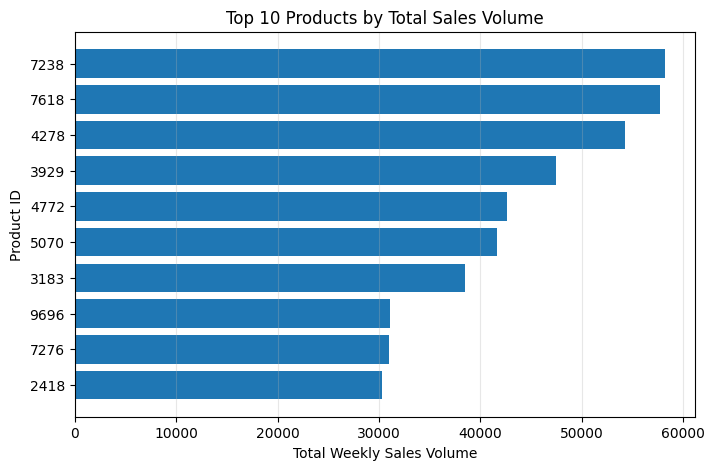

In [99]:
import matplotlib.pyplot as plt

top_products_pd = (
    top_products
    .limit(10)
    .toPandas()
)

top_products_pd = top_products_pd.sort_values("total_volume")

plt.figure(figsize=(8,5))

plt.barh(
    top_products_pd["masked_product_id"].astype(str),
    top_products_pd["total_volume"]
)

plt.title("Top 10 Products by Total Sales Volume")
plt.xlabel("Total Weekly Sales Volume")
plt.ylabel("Product ID")

plt.grid(axis="x", alpha=0.3)

plt.show()

## Observation: Top Product Concentration

A relatively small number of products account for a disproportionately large share of total sales volume. These high-volume products serve as representative candidates for analysing temporal demand patterns because they provide sufficiently long and stable demand histories while remaining operationally important from a business perspective.

### Weekly Demand Trends for Representative High-Volume Products

In [100]:
# Prepare Top Product Dataset
top_10_ids = [
    7238, 7618, 4278, 3929, 5070,
    4772, 3183, 7276, 9696, 2418
]

top_products_df = (
    weekly_df
    .filter(
        F.col("masked_product_id").isin(top_10_ids)
    )
)

product_weekly = (
    top_products_df
    .groupBy(
        "masked_product_id",
        "week_start"
    )
    .agg(
        F.sum("weekly_volume").alias("weekly_volume")
    )
)

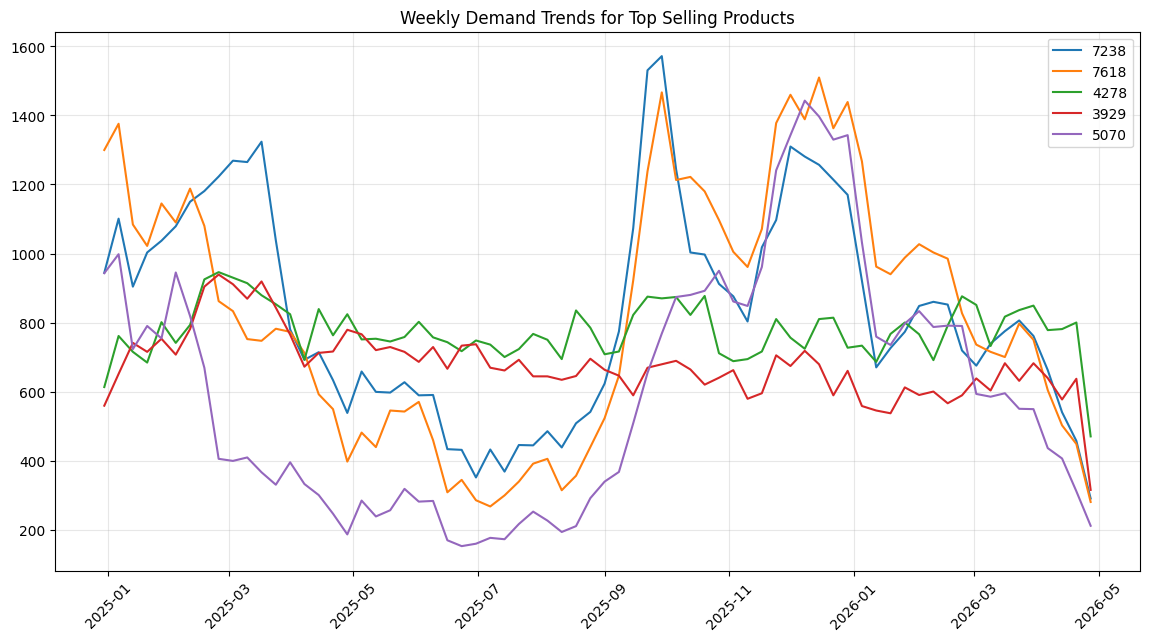

In [101]:
# Visualize weekly demand trends for the top-selling products to identify
# common patterns, seasonal effects, and unusual spikes.

plt.figure(figsize=(14,7))

for pid in top_10_ids[:5]:

    temp = (
        product_weekly
        .filter(F.col("masked_product_id")==pid)
        .orderBy("week_start")
        .toPandas()
    )

    plt.plot(
        temp["week_start"],
        temp["weekly_volume"],
        label=str(pid)
    )

plt.legend()

plt.title("Weekly Demand Trends for Top Selling Products")

plt.xticks(rotation=45)

plt.grid(alpha=0.3)

plt.show()

## Observation: Top Product Trend Analysis

Although the top-selling products differ in baseline demand levels, several exhibit a synchronized increase in weekly sales during the December 2025 to January 2026 period. The consistency of this behaviour across multiple products suggests the influence of a broader seasonal or market-wide demand event rather than isolated product-specific fluctuations. This pattern motivates further investigation into holiday and promotional effects during the year-end period.

## Year-End Demand Spike Investigation

The synchronized increase observed across multiple high-volume products is examined further to determine whether the surge is primarily driven by promotional activity or broader seasonal demand.

In [102]:
# Investigate whether the year-end demand surge is associated with unusually large discounts across the retail network.

weekly_df.filter(
    (F.col("week_start") >= "2025-11-01") &
    (F.col("week_start") <= "2026-01-31")
).groupBy(
    "week_start"
).agg(
    F.sum("weekly_volume").alias("total_volume"),
    F.avg("price_drop_pct").alias("avg_discount")
).orderBy(
    "week_start"
)

DataFrame[week_start: date, total_volume: double, avg_discount: double]

## Observation: Year-End Demand Spike Investigation

Weekly demand increases substantially during late November through early January. Although average promotional discounts contribute to higher sales, the timing and consistency of the demand surge across products indicate that seasonal purchasing behaviour, rather than discount depth alone, is the primary driver of year-end demand.

### Weekly Demand and Promotion Activity

The relationship between aggregate weekly demand and promotional activity is examined to evaluate whether changes in demand coincide with changes in promotion frequency throughout the observation period.

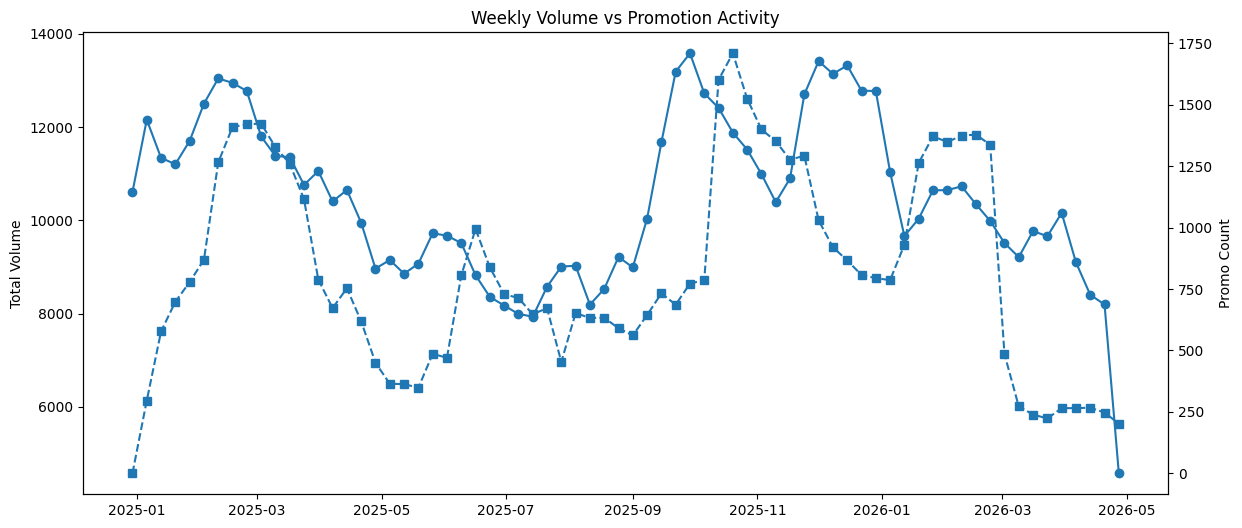

In [103]:
from pyspark.sql import functions as F
import matplotlib.pyplot as plt

# Aggregate weekly demand and promotion activity across the entire portfolio
weekly_summary = (
    weekly_df
    .groupBy("week_start")
    .agg(
        F.sum("weekly_volume").alias("total_volume"),
        F.sum("promo_flag").alias("promo_count")
    )
    .orderBy("week_start")
)

# Convert to Pandas
weekly_summary_pd = weekly_summary.toPandas()

# Plot
fig, ax1 = plt.subplots(figsize=(14,6))

# Total Volume
ax1.plot(
    weekly_summary_pd["week_start"],
    weekly_summary_pd["total_volume"],
    marker="o",
    label="Total Volume"
)
ax1.set_ylabel("Total Volume")

# Promo Count
ax2 = ax1.twinx()
ax2.plot(
    weekly_summary_pd["week_start"],
    weekly_summary_pd["promo_count"],
    linestyle="--",
    marker="s",
    label="Promo Count"
)
ax2.set_ylabel("Promo Count")

plt.title("Weekly Volume vs Promotion Activity")
plt.xlabel("Week")
plt.show()

In [104]:
# Promotion sensitivity of top products

from pyspark.sql import functions as F

# Promotion lift for top products
promo_lift = (
    top_products_df
    .groupBy(
        "masked_product_id",
        "promo_flag"
    )
    .agg(
        F.avg("weekly_volume").alias("avg_volume")
    )
    .groupBy("masked_product_id")
    .pivot("promo_flag", [0, 1])
    .agg(F.first("avg_volume"))
    .withColumnRenamed("0", "non_promo_volume")
    .withColumnRenamed("1", "promo_volume")
    .withColumn(
        "promo_lift",
        F.round(
            F.col("promo_volume") / F.col("non_promo_volume"),
            2
        )
    )
    .orderBy(F.desc("promo_lift"))
)

promo_lift.show(truncate=False)

+-----------------+------------------+------------------+----------+
|masked_product_id|non_promo_volume  |promo_volume      |promo_lift|
+-----------------+------------------+------------------+----------+
|7276             |1.8927217589082639|3.8180560359737115|2.02      |
|5070             |2.610775572811811 |5.038811188811189 |1.93      |
|9696             |2.0018238929982775|3.4062312762133016|1.7       |
|2418             |2.0060834298957126|3.15785975407112  |1.57      |
|3183             |2.51448199034534  |3.8230383973288813|1.52      |
|7618             |3.7830412559328224|5.710517059444249 |1.51      |
|7238             |3.8840799318117245|5.4364152729567685|1.4       |
|3929             |3.4087449106036467|4.614189539098913 |1.35      |
|4278             |3.7263001209414828|4.785018474974807 |1.28      |
|4772             |2.893724585119244 |3.551581243184297 |1.23      |
+-----------------+------------------+------------------+----------+



## Observation: Promotion Sensitivity of Top Products

All high-volume products experience increased demand during promotional periods, with promotion lift ranging from approximately **1.3× to nearly 2×**. While the magnitude differs across products, the consistently positive promotion lift indicates that promotional pricing is an important demand driver even among the highest-selling SKUs. This reinforces the inclusion of promotion-related features within the forecasting pipeline.

In [105]:
dec_spike = (
    weekly_df
    .filter(
        (F.col("week_start") >= "2025-11-01") &
        (F.col("week_start") <= "2026-01-31")
    )
    .groupBy("week_start")
    .agg(
        F.sum("weekly_volume").alias("total_volume"),
        F.sum("promo_flag").alias("promo_count")
    )
    .orderBy("week_start")
)

df = dec_spike.toPandas()

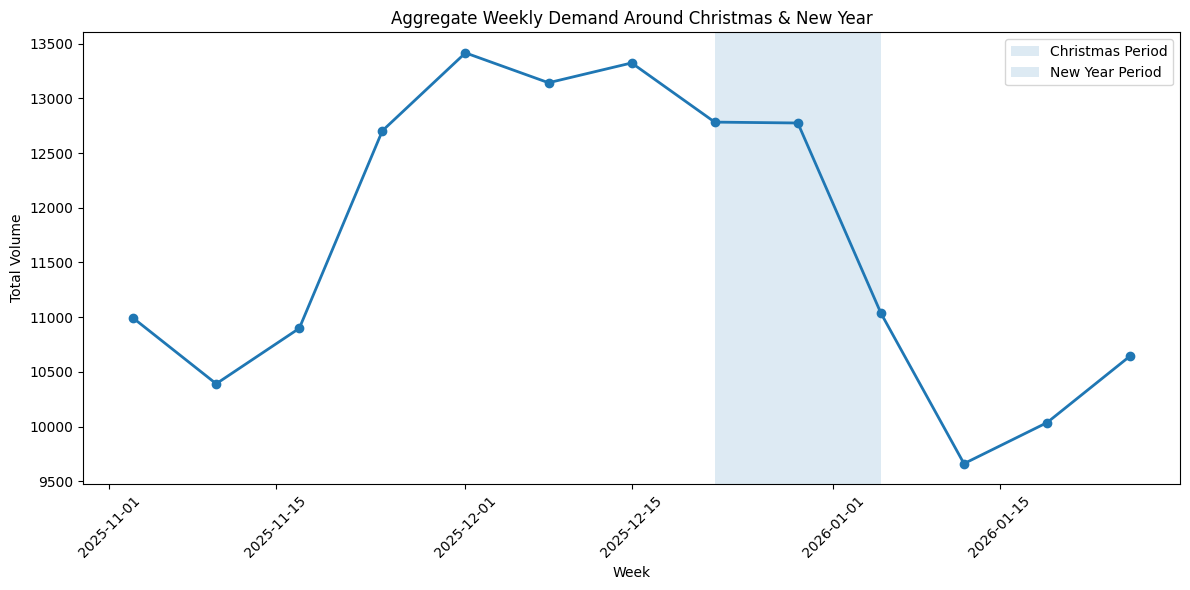

In [106]:
import pandas as pd

plt.figure(figsize=(12,6))

plt.plot(
    df["week_start"],
    df["total_volume"],
    marker="o",
    linewidth=2
)

plt.axvspan(
    pd.Timestamp("2025-12-22"),
    pd.Timestamp("2025-12-29"),
    alpha=0.15,
    label="Christmas Period"
)

plt.axvspan(
    pd.Timestamp("2025-12-29"),
    pd.Timestamp("2026-01-05"),
    alpha=0.15,
    label="New Year Period"
)

plt.title(
    "Aggregate Weekly Demand Around Christmas & New Year"
)

plt.xlabel("Week")
plt.ylabel("Total Volume")

plt.legend()

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

## Observation: Christmas and New Year Demand Surge

Aggregate demand reaches its highest levels during the Christmas and New Year period, confirming the presence of a strong seasonal demand surge. While promotional activity contributes to increased sales, the persistence of elevated demand throughout the holiday period suggests that broader consumer purchasing behaviour plays a dominant role in shaping year-end demand.

In [107]:
forecastability = (
    weekly_df
    .groupBy("masked_product_id")
    .agg(
        F.mean("weekly_volume").alias("mean"),
        F.stddev("weekly_volume").alias("std")
    )
    .withColumn(
        "cv",
        F.col("std") / F.col("mean")
    )
)

array([[<Axes: title={'center': 'cv'}>]], dtype=object)

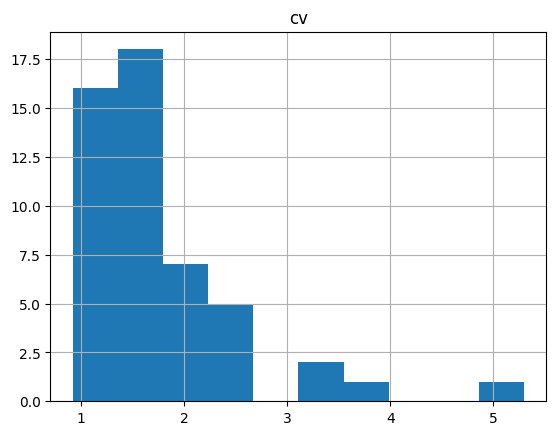

In [108]:
forecastability.select("cv").toPandas().hist()

In [109]:
# Visualize variation in average weekly demand across stores
# to identify differences in store-level demand intensity.
store_stats = (
    weekly_df
    .groupBy("masked_store_id")
    .agg(
        F.avg("weekly_volume").alias("avg_volume"),
        F.avg("promo_flag").alias("promo_rate")
    )
)


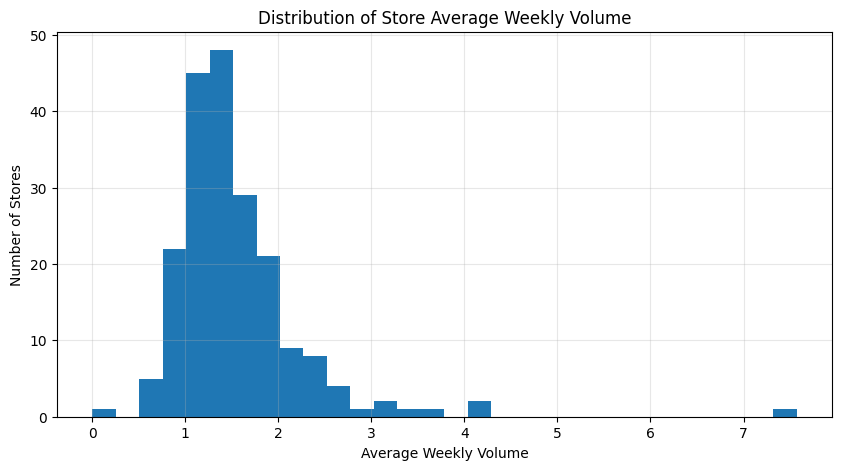

In [110]:
store_pd = store_stats.toPandas()

plt.figure(figsize=(10,5))

plt.hist(
    store_pd["avg_volume"],
    bins=30
)

plt.title("Distribution of Store Average Weekly Volume")
plt.xlabel("Average Weekly Volume")
plt.ylabel("Number of Stores")

plt.grid(alpha=0.3)

plt.show()

## Observation: Store Demand Distribution

Average weekly demand differs considerably across stores, reflecting heterogeneous customer purchasing behaviour and store-specific sales potential. This variability suggests that forecasting models should operate at the store–product level rather than relying on aggregate demand estimates.

In [111]:
# Examine how frequently promotions occur across stores
# to identify differences in promotional activity.
product_promo = (
    weekly_df
    .groupBy("masked_product_id")
    .agg(
        F.avg("promo_flag").alias("promo_frequency")
    )
)
#graph 

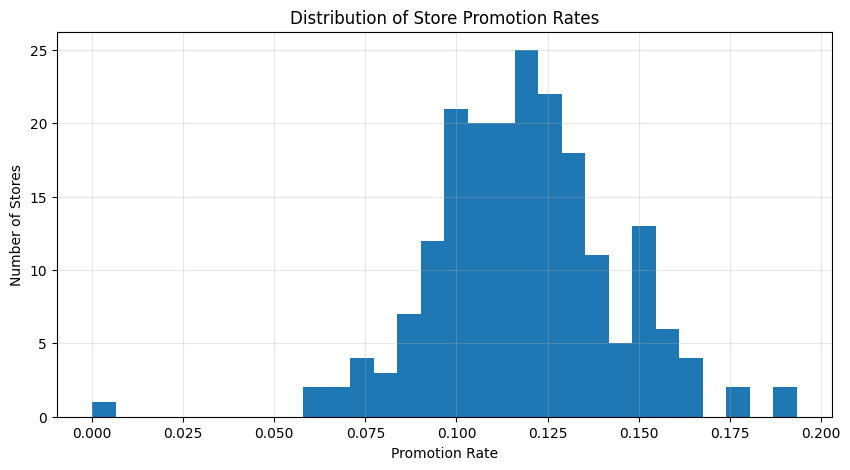

In [112]:
plt.figure(figsize=(10,5))

plt.hist(
    store_pd["promo_rate"],
    bins=30
)

plt.title("Distribution of Store Promotion Rates")
plt.xlabel("Promotion Rate")
plt.ylabel("Number of Stores")

plt.grid(alpha=0.3)

plt.show()

## Observation

Promotion frequency differs across stores, indicating that promotional strategies are implemented unevenly across the retail network. Consequently, promotion-related demand uplift is expected to vary by location and should be considered when interpreting store-level demand behaviour.

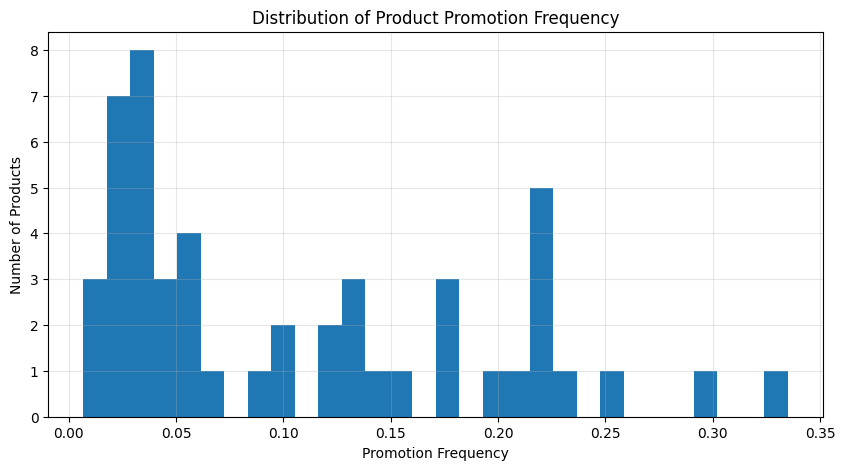

In [113]:
promo_pd = product_promo.toPandas()

plt.figure(figsize=(10,5))

plt.hist(
    promo_pd["promo_frequency"],
    bins=30
)

plt.title("Distribution of Product Promotion Frequency")
plt.xlabel("Promotion Frequency")
plt.ylabel("Number of Products")

plt.grid(alpha=0.3)

plt.show()

## Observation

Most products experience relatively infrequent promotions, while a smaller subset is promoted much more aggressively. This concentrated promotional strategy suggests that pricing interventions are targeted toward selected products rather than applied uniformly across the assortment.

In [114]:
# Analyze average weekly demand by calendar month to identify recurring seasonal patterns and determine whether the observed year-end spike reflects broader seasonality.
from pyspark.sql import functions as F

monthly_seasonality = (
    weekly_df
    .withColumn(
        "month",
        F.month("week_start")
    )
    .groupBy("month")
    .agg(
        F.avg("weekly_volume").alias("avg_weekly_volume"),
        F.count("*").alias("num_records")
    )
    .orderBy("month")
)

monthly_seasonality.show()

+-----+------------------+-----------+
|month| avg_weekly_volume|num_records|
+-----+------------------+-----------+
|    1|1.6326997470614493|      53768|
|    2|1.7390962818882323|      53468|
|    3|1.5599588649099798|      67096|
|    4|1.3313114847318839|      52757|
|    5|1.3892098010344698|      26487|
|    6| 1.342507460886866|      33173|
|    7|1.2611412225233363|      26568|
|    8|1.2522567703109329|      27916|
|    9| 1.628989286321637|      35282|
|   10|1.6745092627729672|      28987|
|   11|1.5351146601146601|      29304|
|   12| 1.773282656344728|      42886|
+-----+------------------+-----------+



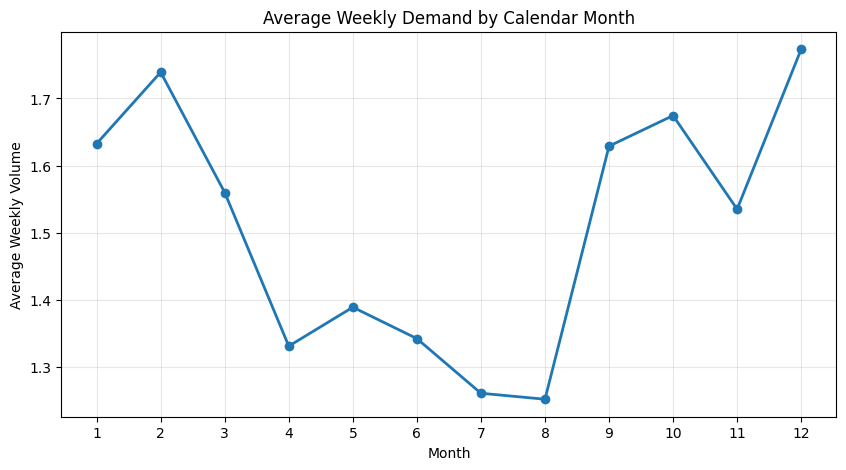

In [115]:
monthly_pd = monthly_seasonality.toPandas()

plt.figure(figsize=(10,5))

plt.plot(
    monthly_pd["month"],
    monthly_pd["avg_weekly_volume"],
    marker="o",
    linewidth=2
)

plt.xticks(range(1,13))

plt.title("Average Weekly Demand by Calendar Month")
plt.xlabel("Month")
plt.ylabel("Average Weekly Volume")

plt.grid(alpha=0.3)

plt.show()

## Observation

Average demand varies across calendar months, indicating recurring seasonal purchasing behaviour. Demand gradually increases toward the year-end holiday period, with December exhibiting the highest average weekly demand. This confirms that seasonal effects complement promotional activity in influencing retail demand.

In [116]:
# Measure demand variability across outlet-product series
# using the coefficient of variation (CV) to evaluate
# forecastability and demand stability.
series_cv = (
    weekly_df
    .groupBy(
        "masked_store_id",
        "masked_product_id"
    )
    .agg(
        F.avg("weekly_volume").alias("mean_volume"),
        F.stddev("weekly_volume").alias("std_volume")
    )
    .filter(F.col("mean_volume") > 0)
    .withColumn(
        "cv",
        F.col("std_volume") / F.col("mean_volume")
    )
)


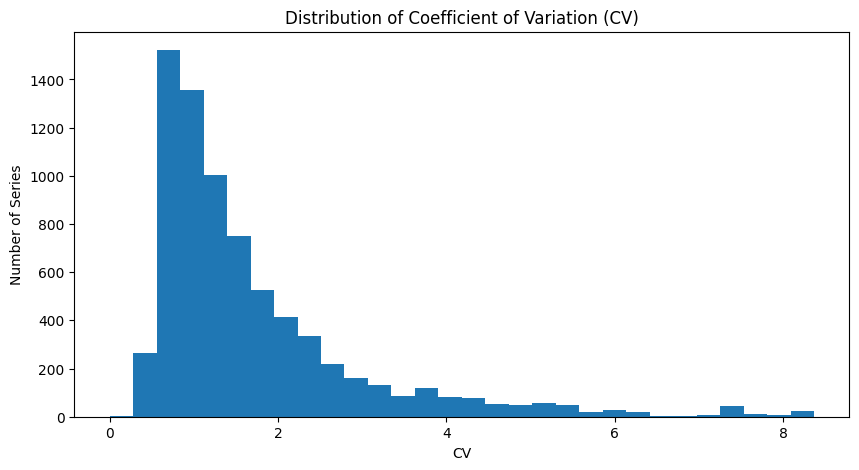

In [117]:
cv_pd = series_cv.select("cv").toPandas()

plt.figure(figsize=(10,5))

plt.hist(
    cv_pd["cv"],
    bins=30
)

plt.title("Distribution of Coefficient of Variation (CV)")
plt.xlabel("CV")
plt.ylabel("Number of Series")

plt.show()

In [ ]:
series_cv = (
    series_cv
    .withColumn(
        "cv_bucket",
        F.when(F.col("cv") < 0.5, "Low")
         .when(F.col("cv") < 1.0, "Moderate")
         .when(F.col("cv") < 2.0, "High")
         .otherwise("Very High")
    )
)

series_cv.groupBy("cv_bucket").count().show()

+---------+-----+
|cv_bucket|count|
+---------+-----+
|     High| 2875|
|Very High| 1898|
|      Low|  116|
| Moderate| 2526|
+---------+-----+



26/06/30 00:23:55 WARN HeartbeatReceiver: Removing executor driver with no recent heartbeats: 931867 ms exceeds timeout 120000 ms
26/06/30 00:23:55 WARN SparkContext: Killing executors is not supported by current scheduler.
26/06/30 00:24:26 WARN Executor: Issue communicating with driver in heartbeater
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:53)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:359)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEndpointRef.askSync(RpcEndpointRef.scala:101)
	at org.apache.spark.rpc.RpcEndpointRef.askSync(RpcEndpointRef.scala:85)
	at org.apache.spark.storage.BlockManagerMaster.registerBlockManager(BlockManagerMaster.scala:81)
	at org.apache.spark.storage.BlockManager.reregister(BlockManager.scala:674)
	at org.apache.spark.executor.Executor.reportHeartBeat(Executor.scala:1530)
	at o

## Observation

A substantial proportion of outlet–product series fall within the High and Very High coefficient of variation categories, indicating considerable demand uncertainty. Combined with the previously identified intermittent demand characteristics, these findings demonstrate that many series are inherently difficult to forecast using conventional statistical techniques.

## Business Implications

The exploratory analysis reveals that retail demand is primarily characterized by intermittent purchasing behaviour, substantial demand variability, and heterogeneous promotional response across products and stores. Promotional pricing emerges as the strongest controllable demand driver, while holiday periods and seasonal effects provide additional but comparatively moderate demand uplift. Together, these findings indicate that reliable forecasting requires methods capable of handling sparse demand, incorporating promotion-related information, and accounting for calendar effects. These observations directly motivate the evaluation of intermittent-demand forecasting techniques in the subsequent modelling phase.

## Final Conclusion

The exploratory data analysis demonstrates that demand at the store–product level is predominantly intermittent, highly variable, and strongly influenced by promotional activity. While holiday periods contribute moderate seasonal demand uplift, promotional pricing represents the primary controllable driver of sales variation. The prevalence of intermittent and lumpy demand patterns, together with high demand variability, confirms that conventional forecasting approaches are unlikely to perform consistently across the dataset. These findings provide a strong analytical foundation for evaluating specialized intermittent-demand forecasting methods in the modelling phase.

# Key EDA Findings

Intermittent demand dominates (~62%)

Promotions ≈ strongest driver

Holidays ≈ moderate effect

Demand varies by store and product

Weekly aggregation appropriate

Intermittent forecasting methods justified